In [1]:
# SONDEWNPN
# Balloon-borne sounding system (BBSS): Vaisala-processed winds, press., temp, &RH
# Data Level: b1
# Site: Houston, TX; Tracking Aerosol Convection interactions ExpeRiment (HOU)
# Facility: Houston, TX; AMF1 (main site for TRACER) (M1)
# Category: Atmospheric Profiling
# Source Instrument/Data: Balloon-Borne Sounding System (sonde)
# Date Range: 2021-09-30 to 2021-11-08

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
data_location='/mnt/lustre/koa/koastore/torri_group/air/dropsonde_data/'
count_nc=0
nc_filenames = []
for i, file_name in enumerate(os.listdir(data_location), start=1):
    if file_name.endswith(".cdf"): 
        count_nc+=1
        nc_filenames.append(file_name) 
# print(f'num files: {len(nc_filenames)}') 

date='20220622.17'
print([t for t in nc_filenames if date[:8] in t])
which_file=nc_filenames.index([t for t in nc_filenames if date in t][0])

data=xr.open_dataset(data_location+'/'+nc_filenames[int(which_file)])
var_list= [x for x in data]; 
print(nc_filenames[int(which_file)])

['housondewnpnM1.b1.20220622.173100.cdf', 'housondewnpnM1.b1.20220622.203000.cdf', 'housondewnpnM1.b1.20220622.112900.cdf', 'housondewnpnM1.b1.20220622.233000.cdf', 'housondewnpnM1.b1.20220622.052900.cdf']
housondewnpnM1.b1.20220622.173100.cdf


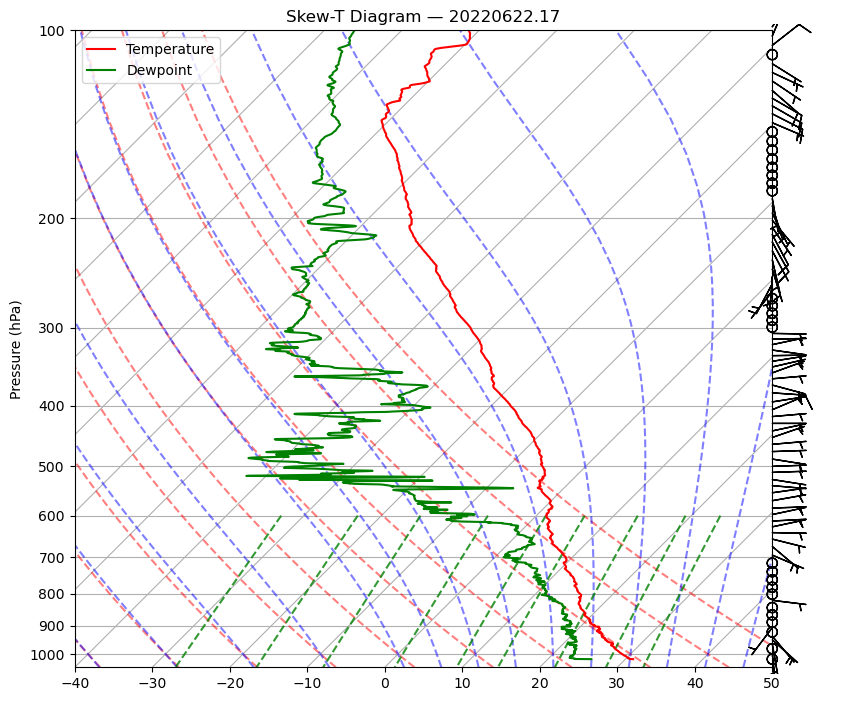

In [4]:
# import matplotlib.pyplot as plt
from datetime import datetime
from metpy.plots import SkewT
from metpy.units import units
from metpy.io import parse_metar_file

# Extract variables from the data
pressure = data['pres'] * units('hPa')
temperature = data['tdry'] * units('degC')
dewpoint = data['dp'] * units('degC')
u_wind = data['u_wind'] * units('m/s') 
v_wind = data['v_wind'] * units('m/s') 
wind_direction = data['deg'] * units('degrees')
relative_humidity = data['rh'] * units('percent')

# Create a new figure
fig = plt.figure(figsize=(9, 9))

# Add a SkewT subplot
skew = SkewT(fig, rotation=45)

# Plot the data on the SkewT plot
skew.plot(pressure, temperature, 'r', label='Temperature')
skew.plot(pressure, dewpoint, 'g', label='Dewpoint')
step=40; skew.plot_barbs(pressure[::step], u_wind[::step], v_wind[::step],y_clip_radius=0.01)

# # Add relative humidity
# ax2 = skew.ax.twiny()
# ax2.plot(relative_humidity, pressure,'b', label='Relative Humidity')
# ax2.set_ylabel('Pressure (hPa)')

# Add legend and title
plt.legend(loc='upper left')
plt.title(f'Skew-T Diagram \u2014 {date}')
plt.ylabel('Pressure (hPa)')
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()

plt.savefig(os.path.join("skewt/", f"{date}.jpg"),dpi=72)

original wind magnitude [  4.          1.21        1.2100002 ... 176.89001   176.89
 179.56     ]
rotated wind magnitude [  4.00000022   1.2100001    1.21000017 ... 176.89000279 176.88999449
 179.55999699]


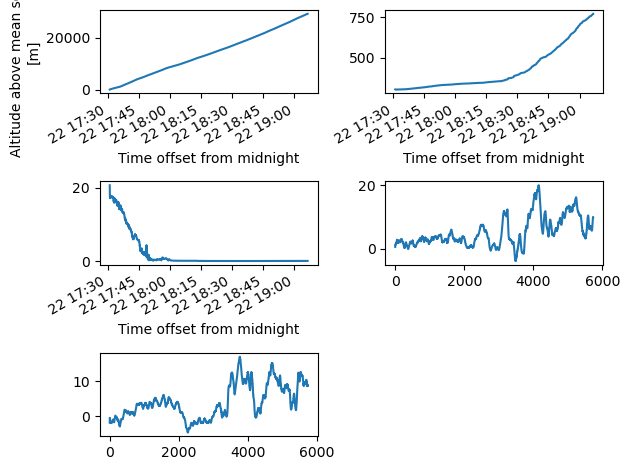

In [5]:
plt.subplot(3,2,1)
alt=data[var_list[int(var_list.index('alt'))]] 
alt.plot()

plt.subplot(3,2,2)
tdry=data[var_list[int(var_list.index('tdry'))]] 
pres=data[var_list[int(var_list.index('pres'))]] 
tdry=tdry+273.15 #convert to Kelvin
pot_temp=tdry*(1000/pres)**(0.2854) #convert to potential tmperature
pot_temp.plot()
pot_temp

plt.subplot(3,2,3)
RH=data[var_list[int(var_list.index('rh'))]]/100
#Calculation for Mixing Ratio
#Kerry Emanuel 1994
Rd=287
Rv=461
eps= Rd/Rv
e_star = np.exp(53.67957-(6743.769/tdry)-4.8451*np.log(tdry))
e = RH*e_star
# spec_humid = (eps*e)/((pres*100)-e*(1-eps))
mix_ratio = (eps*e)*1000/(pres-e)
mix_ratio.plot()

#winds
u_wind=data[var_list[int(var_list.index('u_wind'))]] 
v_wind=data[var_list[int(var_list.index('v_wind'))]]
print(f'original wind magnitude {u_wind.values**2+v_wind.values**2}')
#rotate winds to match coastline orientation
def rotation(theta):
    rotation_mat=np.array([[np.cos(theta), -np.sin(theta)],
                            [np.sin(theta), np.cos(theta)]])
    return rotation_mat

#picks out each index of u and v 
theta=-(45+90)
rotation_mat=rotation(np.radians(theta))
uv_vec=np.vstack([u_wind, v_wind]); uv_vec=np.dot(rotation_mat,uv_vec)
u_wind=uv_vec[0];v_wind=uv_vec[1]
print(f'rotated wind magnitude {u_wind**2+v_wind**2}')

plt.subplot(3,2,4)
plt.plot(u_wind)
plt.subplot(3,2,5)
plt.plot(v_wind)

plt.tight_layout()

In [8]:
file_path = 'input_sounding.txt'

# Open the file in write mode
with open(file_path, 'w') as file:
    
    #this needs to be fixed to start at the correct value ***
    line = "{:>9.4f} {:>10.4f} {:>10.4f}\n".format(pres.values[0],pot_temp.values[0],mix_ratio.values[0])
    file.write(line)
        
    for i in range(0,len(alt)):
        var1=np.round(alt.values[i],4)
        var2=np.round(pot_temp.values[i],4)
        var3=np.round(mix_ratio.values[i],4)
        var4=np.round(u_wind[i],4);
        var5=np.round(v_wind[i],4);

        #zero velocity case #comment if not using
        # var4=0
        # var5=0
        
        line = "{:>9.4f} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}\n".format(var1, var2, var3, var4, var5)
        file.write(line)

In [3]:
## Converts all figures to PDF
######################################################################################################################################################
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import os

def jpg_to_pdf(input_folder, output_pdf):
    # Get a list of all JPG files in the input folder
    jpg_files = [file for file in os.listdir(input_folder) if file.endswith('.jpg')]
    jpg_files = sorted(jpg_files, key=lambda x: (int(x[:8]), int(x[9:11])))
    
    # Create a PDF canvas
    c = canvas.Canvas(output_pdf, pagesize=letter)

    # Loop through each JPG file and add it to the PDF
    for jpg_file in jpg_files:
        # Open the JPG image using PIL
        img = Image.open(os.path.join(input_folder, jpg_file))

        # Calculate the aspect ratio to maintain image proportions
        width, height = img.size
        aspect_ratio = width / height

        # Add the image to the PDF
        c.setPageSize((width, height))
        c.drawInlineImage(os.path.join(input_folder, jpg_file), 0, 0, width=width, height=height)

        # Add a new page for the next image
        c.showPage()

    # Save the PDF
    c.save()

# Example usage:
input_folder = '/mnt/lustre/koa/koastore/torri_group/air/skewt' 
output_pdf = '/mnt/lustre/koa/koastore/torri_group/air/skewt/skewt.pdf'
jpg_to_pdf(input_folder, output_pdf)